In [7]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE
from recommenders.metrics import NDCG_binary_at_k_batch, Recall_at_k_batch_torch, mpr, similarities_score, pairwise_cosine_similarity
import datetime
from recommenders.lmf import LogisticMatrixFactorization
import bottleneck as bn
from scipy.sparse import csr_matrix
from scipy.optimize import linear_sum_assignment

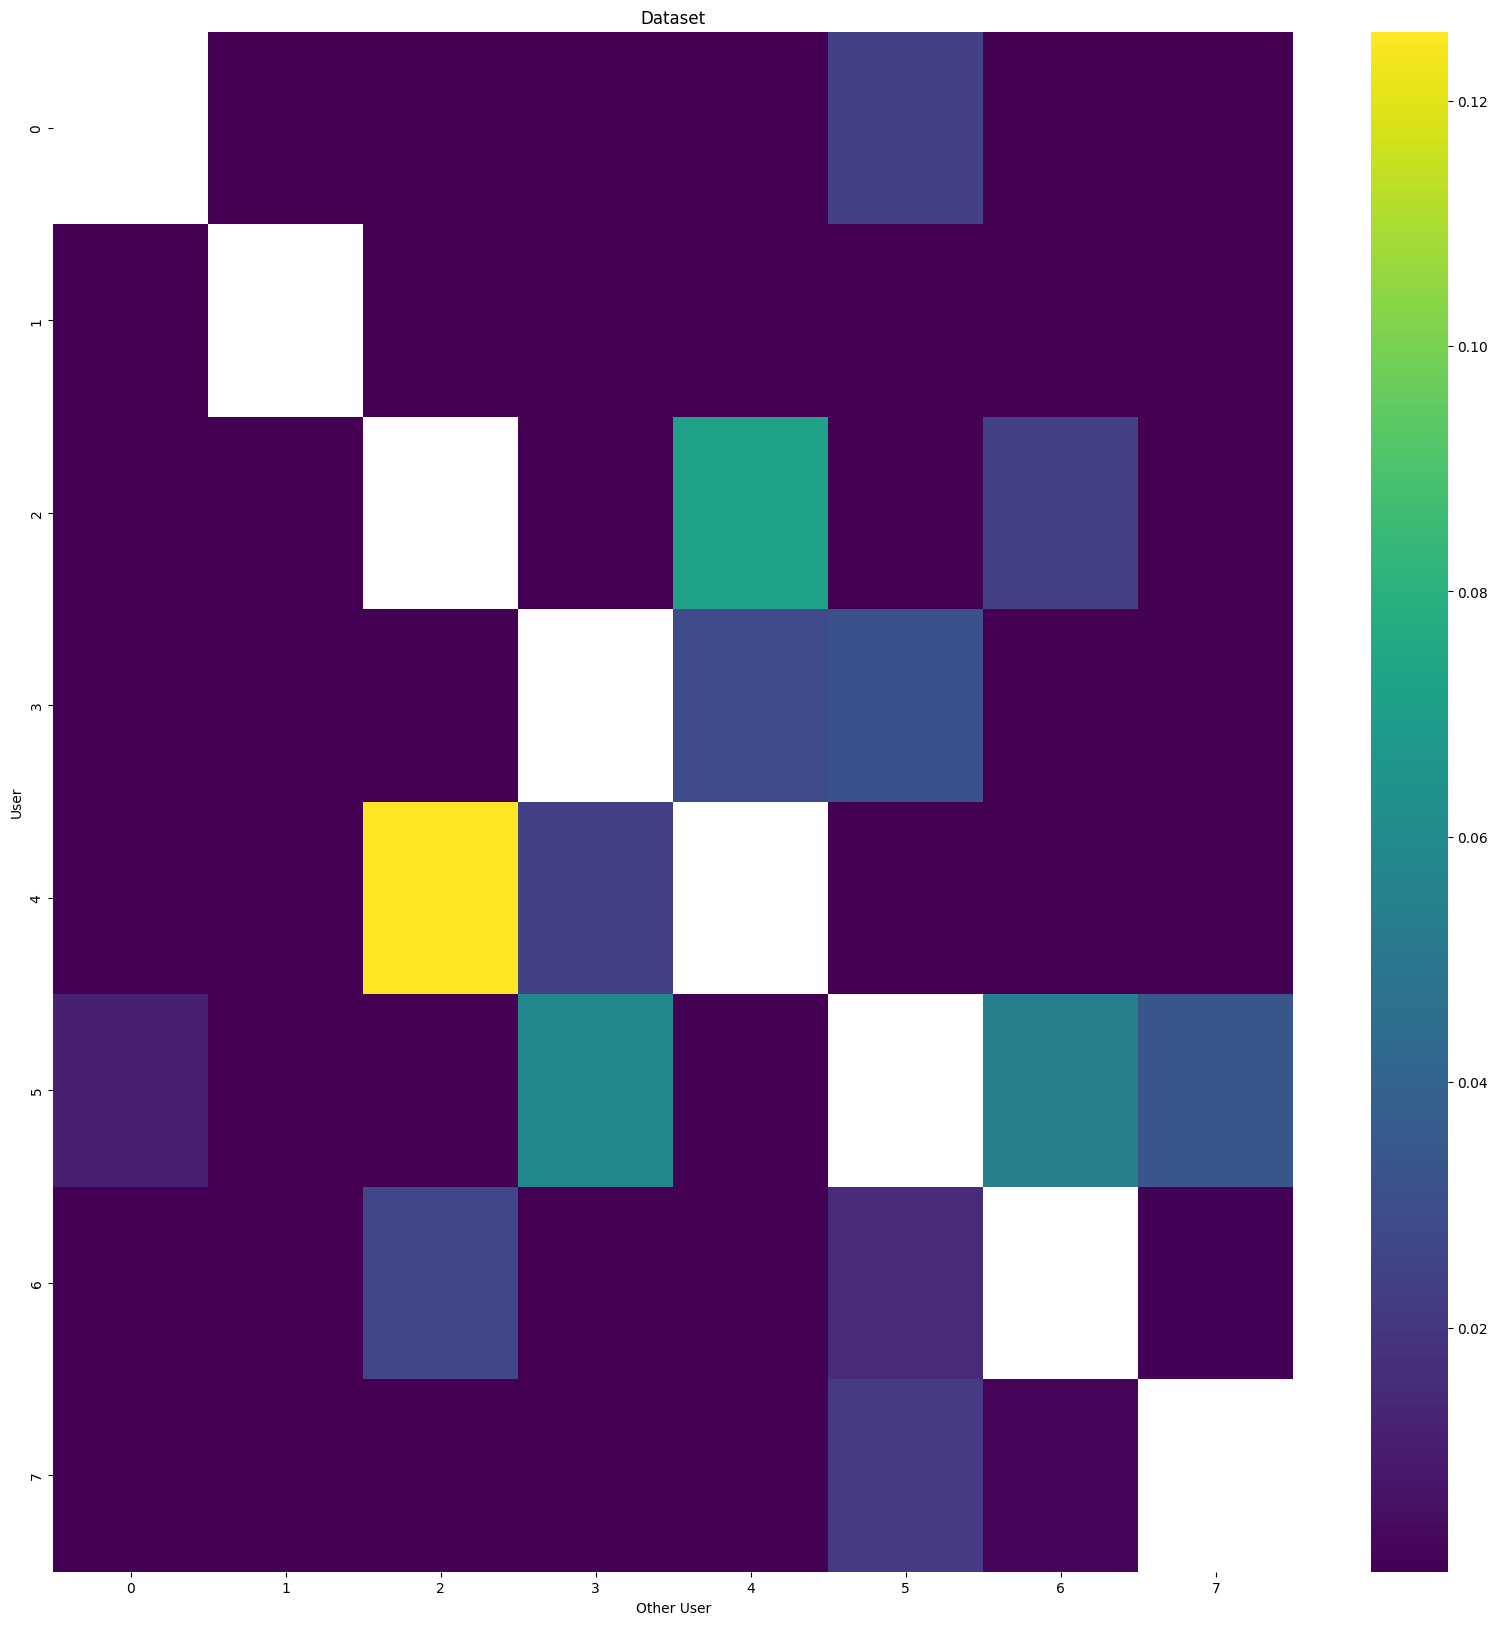

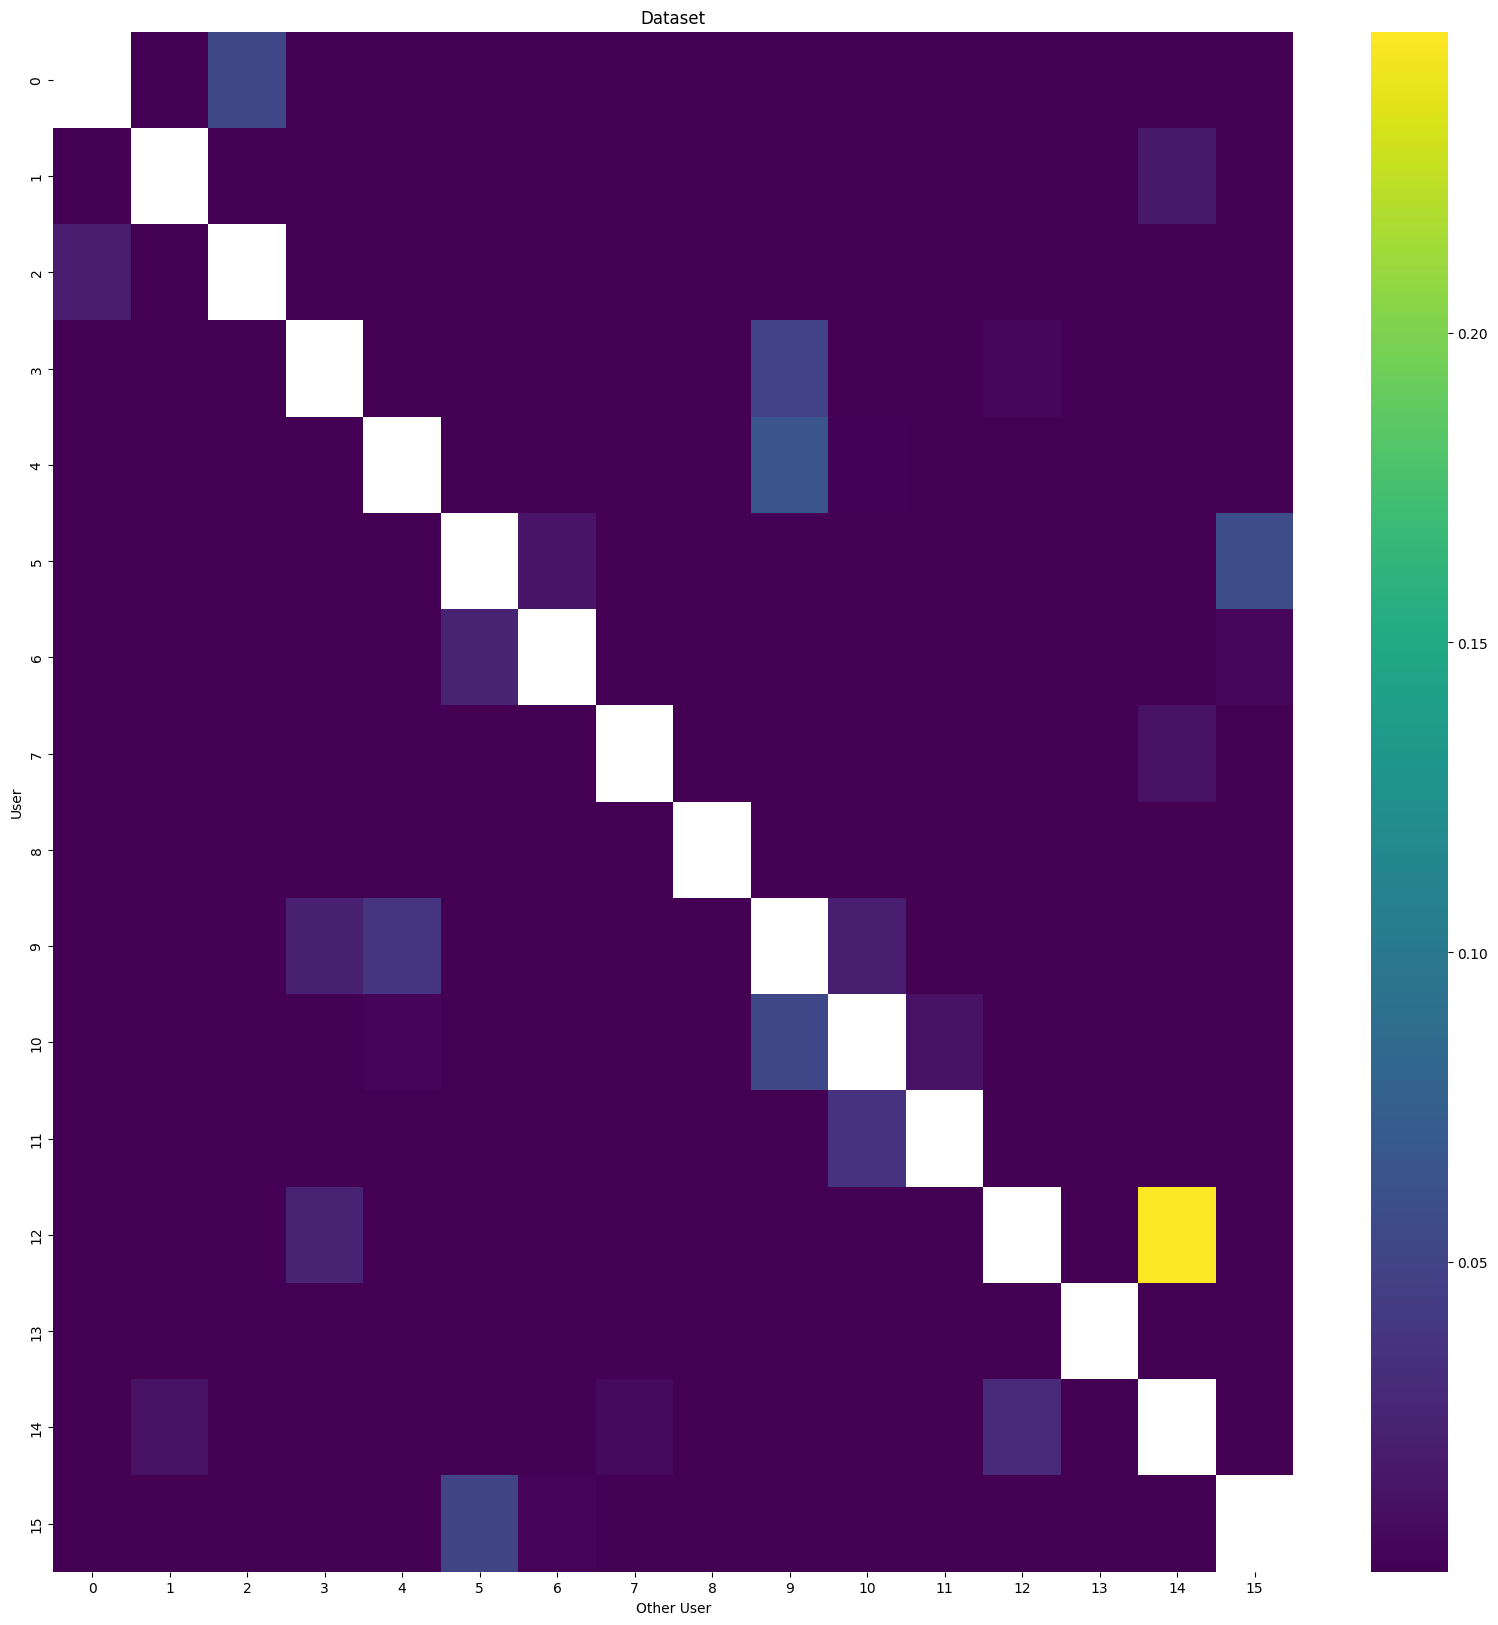

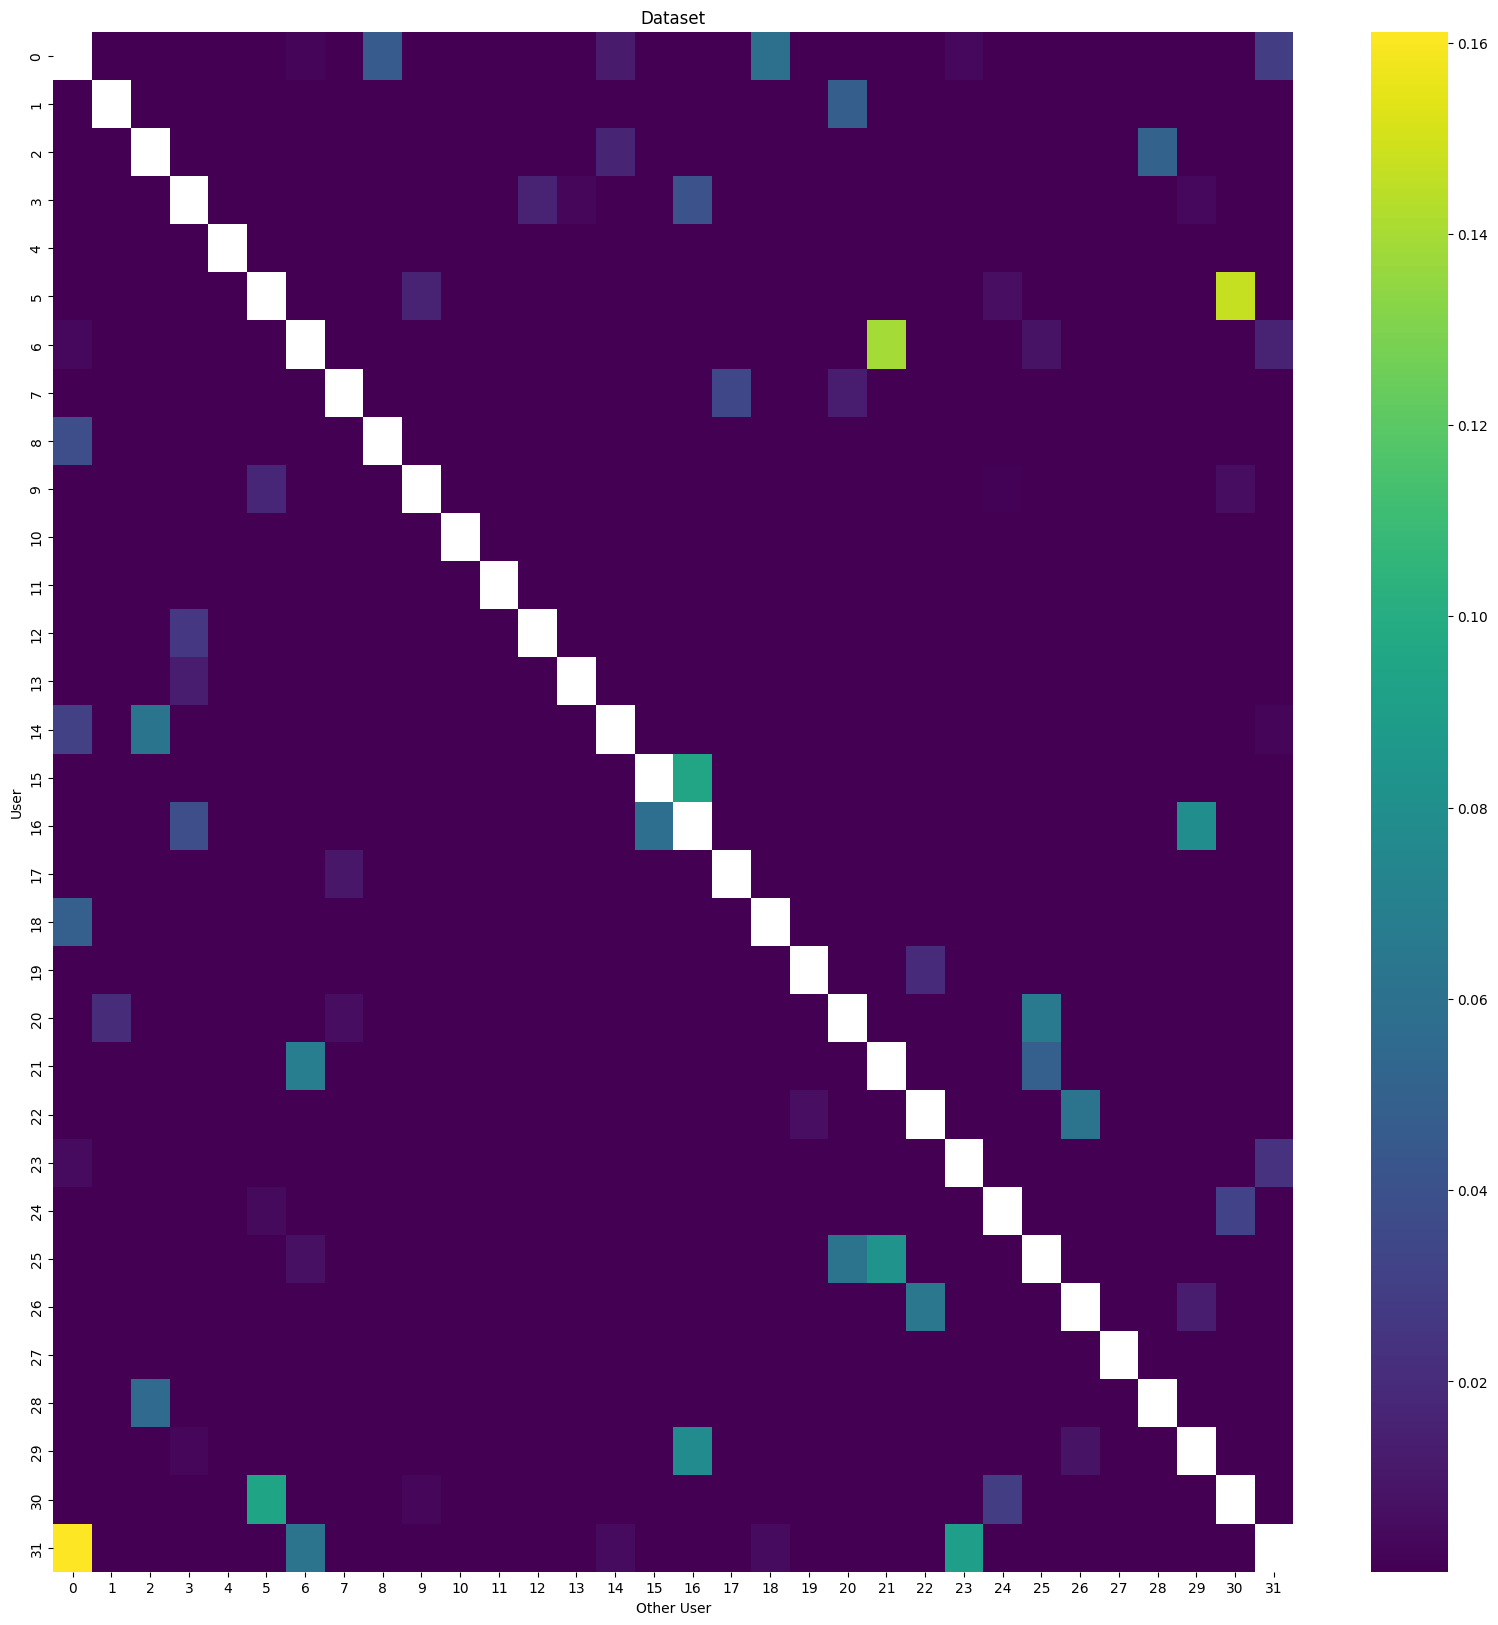

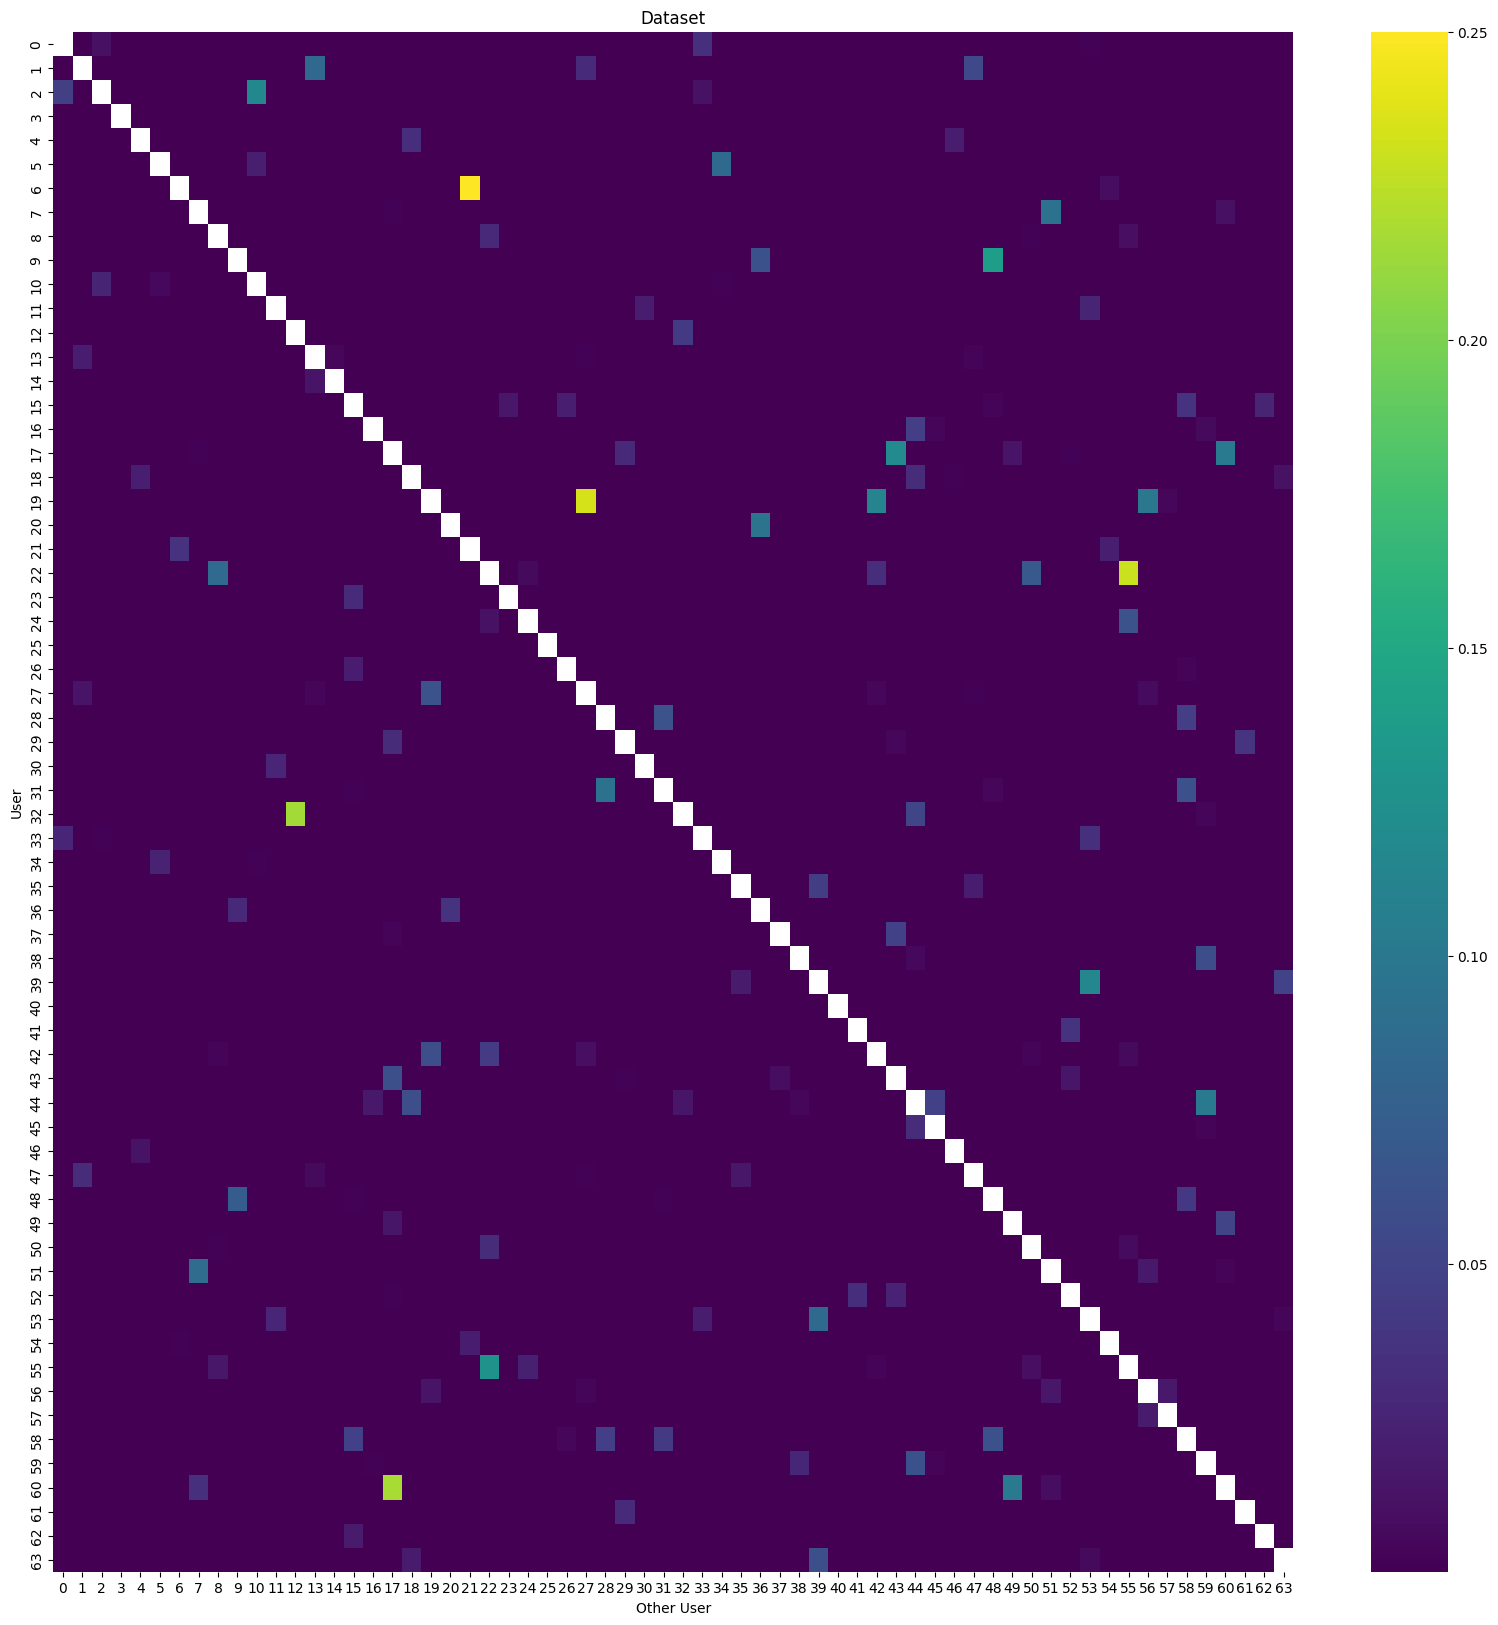

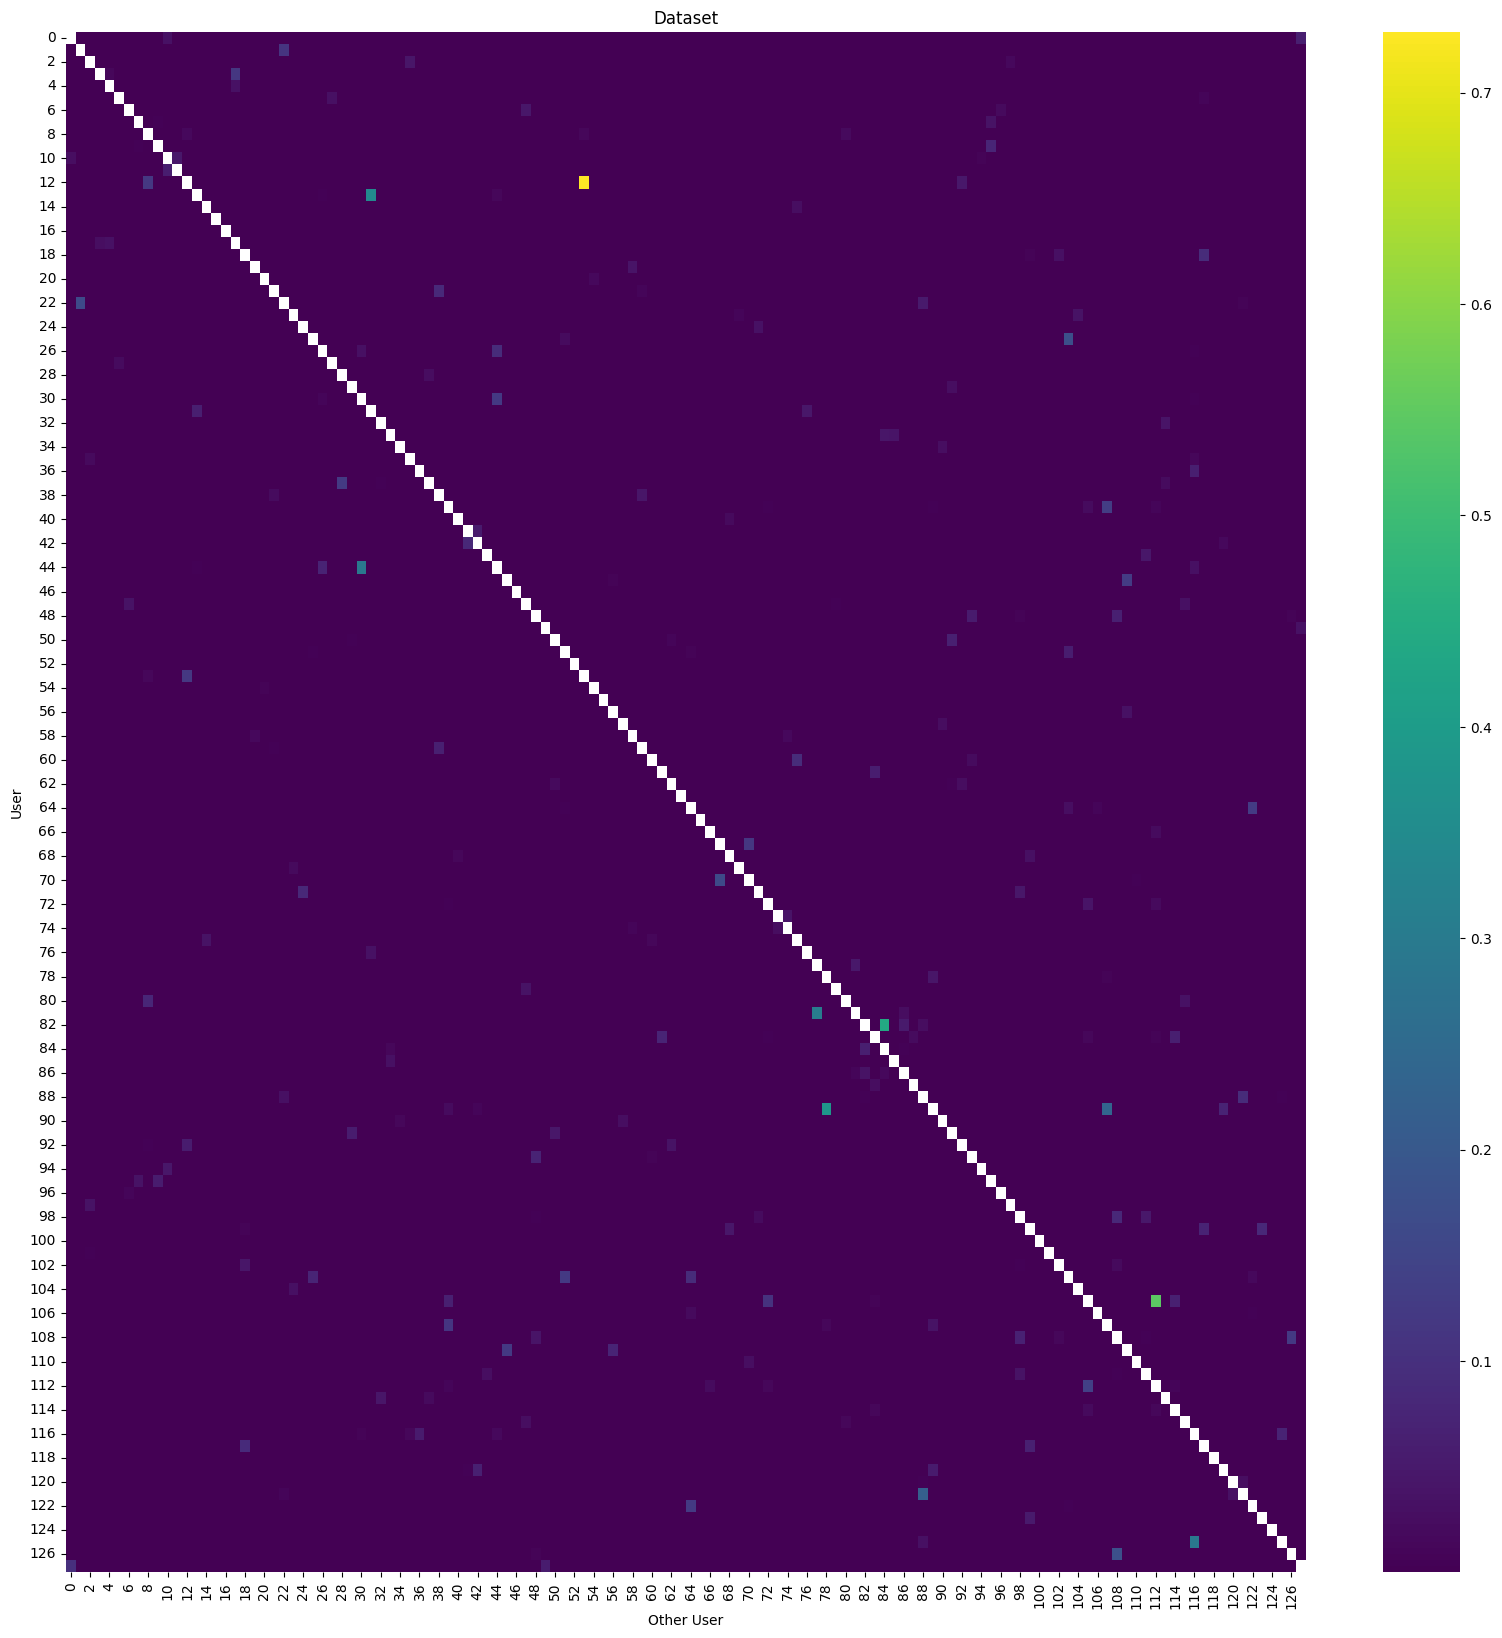

In [37]:
for i in range(3, 8):
    df = pd.read_csv(f"data/artificial_data_{2**i}.csv")
    df_user_similarities = user_similarities.calculate_users_track_common_percentage(df, username_col="username", trackname_col="id")
    plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Dataset")

In [33]:
 # Compute pairwise distances for th matrices

# Example matrices
A = torch.tensor([
    [1, 2, 3],
    [1, 2, 5],
    [1, 2, 4]
], dtype=torch.float64)
B = torch.tensor([
    [1, 200, 3],
    [1, 2, 5],
    [1, 2, 10],
], dtype=torch.float64)
# Create a cost matrix
cost_matrix = 1 - pairwise_cosine_similarity(A, B)
row_ind, col_ind = linear_sum_assignment(cost_matrix.cpu().numpy(), maximize=False)
print(cost_matrix)
print(row_ind, col_ind)
print(cost_matrix[row_ind, col_ind])
print(cost_matrix[row_ind, col_ind].sum())

tensor([[0.4522, 0.0241, 0.0871],
        [0.6203, 0.0000, 0.0200],
        [0.5494, 0.0040, 0.0417]], dtype=torch.float64)
[0 1 2] [0 2 1]
tensor([0.4522, 0.0200, 0.0040], dtype=torch.float64)
tensor(0.4762, dtype=torch.float64)


In [2]:
import torch
from scipy.optimize import linear_sum_assignment

def pairwise_distances(matrix):
    # Expand dimensions for broadcasting
    matrix_expanded = matrix.unsqueeze(1)
    # Compute pairwise Euclidean distances
    distances = torch.norm(matrix_expanded - matrix_expanded.transpose(0, 1), dim=2)
    return distances

def calculate_score(A, B):
    # Compute pairwise distances for both matrices
    dist_A = pairwise_distances(A)
    dist_B = pairwise_distances(B)

    # Create a cost matrix
    cost_matrix = torch.cdist(dist_A, dist_B)

    # Find the optimal assignment
    row_ind, col_ind = linear_sum_assignment(cost_matrix.numpy())

    # Calculate score
    score = cost_matrix[row_ind, col_ind].sum()
    return score

# Example matrices
A = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
B = torch.tensor([[3, 4], [1, 2]], dtype=torch.float32)

similarities_score(A, B)

tensor(0.)

In [2]:
def ndcg_binary_at_k_batch(
    X_pred: torch.Tensor,
    heldout_batch: torch.Tensor,
    k: int = 100,
    device="cpu",
    dtype=torch.float32,
):
    """
    Normalized Discounted Cumulative Gain@k for binary relevance in PyTorch without using for loops
    ASSUMPTIONS: all the 0's in heldout_data indicate 0 relevance

    :param X_pred: The predicted scores.
    :param heldout_batch: The ground truth, it's the matrix of the heldout data (heldout data is the data that we use to test the model).
    :param k: The number of recommendations to consider.
    :return: The Normalized Discounted Cumulative Gain@k for binary relevance.
    """
    batch_users = X_pred.size(0)

    # Use topk to find the top-k indices
    _, idx_topk = X_pred.topk(k, dim=1)
    tp = 1.0 / torch.log2(torch.arange(2, k + 2, device=device, dtype=dtype))

    # Gathering the top-k items
    topk_part = torch.gather(X_pred, 1, idx_topk)

    # Calculating DCG
    DCG = (torch.gather(heldout_batch, 1, idx_topk) * tp).sum(dim=1)

    # Calculating IDCG without a for loop
    count_nonzero = heldout_batch.count_nonzero(dim=1)
    tp_expanded = tp.unsqueeze(0).expand(batch_users, -1)
    IDCG = torch.where(
        count_nonzero.unsqueeze(1) > torch.arange(k, device=device, dtype=dtype),
        tp_expanded,
        torch.zeros_like(tp_expanded, device=device, dtype=dtype),
    ).sum(dim=1)

    return DCG / IDCG

In [3]:
K = 3

In [4]:
R = torch.tensor([
    [234, 0.2, 0.5, 1.0],
    [0.7, 245, 0, 0],
    [0.9, 224, 1.0, 1.0],
])
R

tensor([[2.3400e+02, 2.0000e-01, 5.0000e-01, 1.0000e+00],
        [7.0000e-01, 2.4500e+02, 0.0000e+00, 0.0000e+00],
        [9.0000e-01, 2.2400e+02, 1.0000e+00, 1.0000e+00]])

In [5]:
R.count_nonzero(dim=1)

tensor([4, 2, 4])

In [6]:
I = torch.argsort(R, dim=1, descending=True)
I

tensor([[0, 3, 2, 1],
        [1, 0, 2, 3],
        [1, 2, 3, 0]])

In [7]:
pred = torch.tensor([
    [0.1, 0.2, 0.5, 1.0],
    [0.7, 0.5, 0, 0],
    [0.2, 0.4, 1.0, 1.0],
])
pred

tensor([[0.1000, 0.2000, 0.5000, 1.0000],
        [0.7000, 0.5000, 0.0000, 0.0000],
        [0.2000, 0.4000, 1.0000, 1.0000]])

In [8]:
batch_users = R.size(0)
batch_users

3

In [9]:
_, idx_topk = pred.topk(K, dim=1)
idx_topk

tensor([[3, 2, 1],
        [0, 1, 2],
        [2, 3, 1]])

In [10]:
tp = 1.0 / torch.log2(torch.arange(2, K + 2))
tp

tensor([1.0000, 0.6309, 0.5000])

In [11]:
indexes = torch.arange(R.size(0)).unsqueeze(1).expand(-1, R.size(1))
indexes

tensor([[0, 0, 0, 0],
        [1, 1, 1, 1],
        [2, 2, 2, 2]])

In [12]:
from torchmetrics.retrieval import RetrievalNormalizedDCG
ndcg = RetrievalNormalizedDCG(top_k=3)

ndcg(pred, R, indexes)

tensor(0.3811)

In [13]:

ndcg(preds=pred, target=R, indexes=indices)

NameError: name 'indices' is not defined

In [ ]:
R = R.numpy()

In [ ]:
np.array([(tp[:min(n, K)]).sum()
                    for n in np.count_nonzero(R, axis=1)])

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
IDCG = np.array([(tp[:min(n, K)]).sum()
                    for n in np.count_nonzero(R, axis=1)])
IDCG

array([2.1309297, 1.6309297, 2.1309297], dtype=float32)

In [ ]:
batch_users = R.shape[0]
idx_topk_part = np.argpartition(-pred, K, axis=1)[:, :K]
topk_part = pred[np.arange(batch_users)[:, np.newaxis],
                    idx_topk_part[:, :K]]
idx_part = np.argsort(-topk_part, axis=1)
# X_pred[np.arange(batch_users)[:, np.newaxis], idx_topk] is the sorted
# topk predicted score
idx_topk = idx_topk_part[np.arange(batch_users)[:, np.newaxis], idx_part]
# build the discount template
tp = 1. / np.log2(np.arange(2, K + 2))

DCG = (R[np.arange(batch_users)[:, np.newaxis], idx_topk] * tp).sum(axis=1)

IDCG = np.array([(tp[:min(n, K)]).sum()
                    for n in np.count_nonzero(R, axis=1)])

print(idx_topk_part)
print(topk_part)
print(idx_part)
print(idx_topk)
print(tp)
print(DCG)
print(IDCG)
print(np.mean(DCG / IDCG))

DCG / IDCG

tensor([[0, 1, 3],
        [0, 1, 2],
        [3, 1, 2]])
tensor([[1.0000, 0.5500, 1.0000],
        [0.1230, 0.1000, 0.0000],
        [1.0000, 0.4000, 4.0000]])
tensor([[0, 2, 1],
        [0, 1, 2],
        [2, 0, 1]])
tensor([[0, 3, 1],
        [0, 1, 2],
        [2, 3, 1]])
[1.         0.63092975 0.5       ]
[0.83092976 1.01546486 1.83092976]
[2.13092975 1.63092975 2.13092975]
0.6239278241348388


array([0.38993766, 0.62262943, 0.85921638])